<a href="https://colab.research.google.com/github/SiyuL2025/math_629_final/blob/main/Transformer_v4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# get updated github content
!git clone https://github.com/SiyuL2025/math_629_final.git
!cd /content/math_629_final && git pull

fatal: destination path 'math_629_final' already exists and is not an empty directory.
Already up to date.


In [ ]:
# import data
import sys
sys.path.append('./math_629_final')

import BTC_ETH_pipeline_v4

Device: cuda
  Transformer LOB  |  dataset='no_pca'  |  cost=0

Dataset     : no_pca
Features    : 88  →  ['bids_distance_0', 'asks_distance_0', 'bids_notional_0', 'asks_notional_0'] ...
Train shape : (79826, 88)  |  Test shape : (19957, 88)
Label dist (train) — Down:17,975  Flat:44,145  Up:17,706
Train samples : 79,797  |  Test samples  : 19,928
Class weights (down/flat/up) : [1.48  0.603 1.503]
Model params : 108,419  |  Input features : 88

--- Training ---


/tmp/ipykernel_986/2939650347.py:158: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, N_LAYERS, norm=nn.LayerNorm(D_MODEL))


Ep   1/30 | Train Loss 1.0965 | Val Loss 1.0732 | Val Acc 0.5871
Ep   2/30 | Train Loss 1.0783 | Val Loss 1.0409 | Val Acc 0.5655
Ep   3/30 | Train Loss 1.0583 | Val Loss 1.0186 | Val Acc 0.5386
Ep   4/30 | Train Loss 1.0421 | Val Loss 1.0102 | Val Acc 0.5461
Ep   5/30 | Train Loss 1.0315 | Val Loss 1.0069 | Val Acc 0.5478
Ep   6/30 | Train Loss 1.0219 | Val Loss 1.0035 | Val Acc 0.5489
Ep   7/30 | Train Loss 1.0157 | Val Loss 1.0006 | Val Acc 0.5499
Early stop at epoch 7. Best val acc: 0.5871

--- Prediction ---

  6.1  STATISTICAL PREDICTION METRICS

Overall Accuracy : 0.5871  (58.71%)

              precision    recall  f1-score   support

   Down (-1)     0.2545    0.1184    0.1616      3556
    Flat (0)     0.6530    0.8424    0.7357     12647
     Up (+1)     0.3192    0.1678    0.2200      3725

    accuracy                         0.5871     19928
   macro avg     0.4089    0.3762    0.3724     19928
weighted avg     0.5195    0.5871    0.5369     19928


Class         Precisio

/tmp/ipykernel_986/2939650347.py:417: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


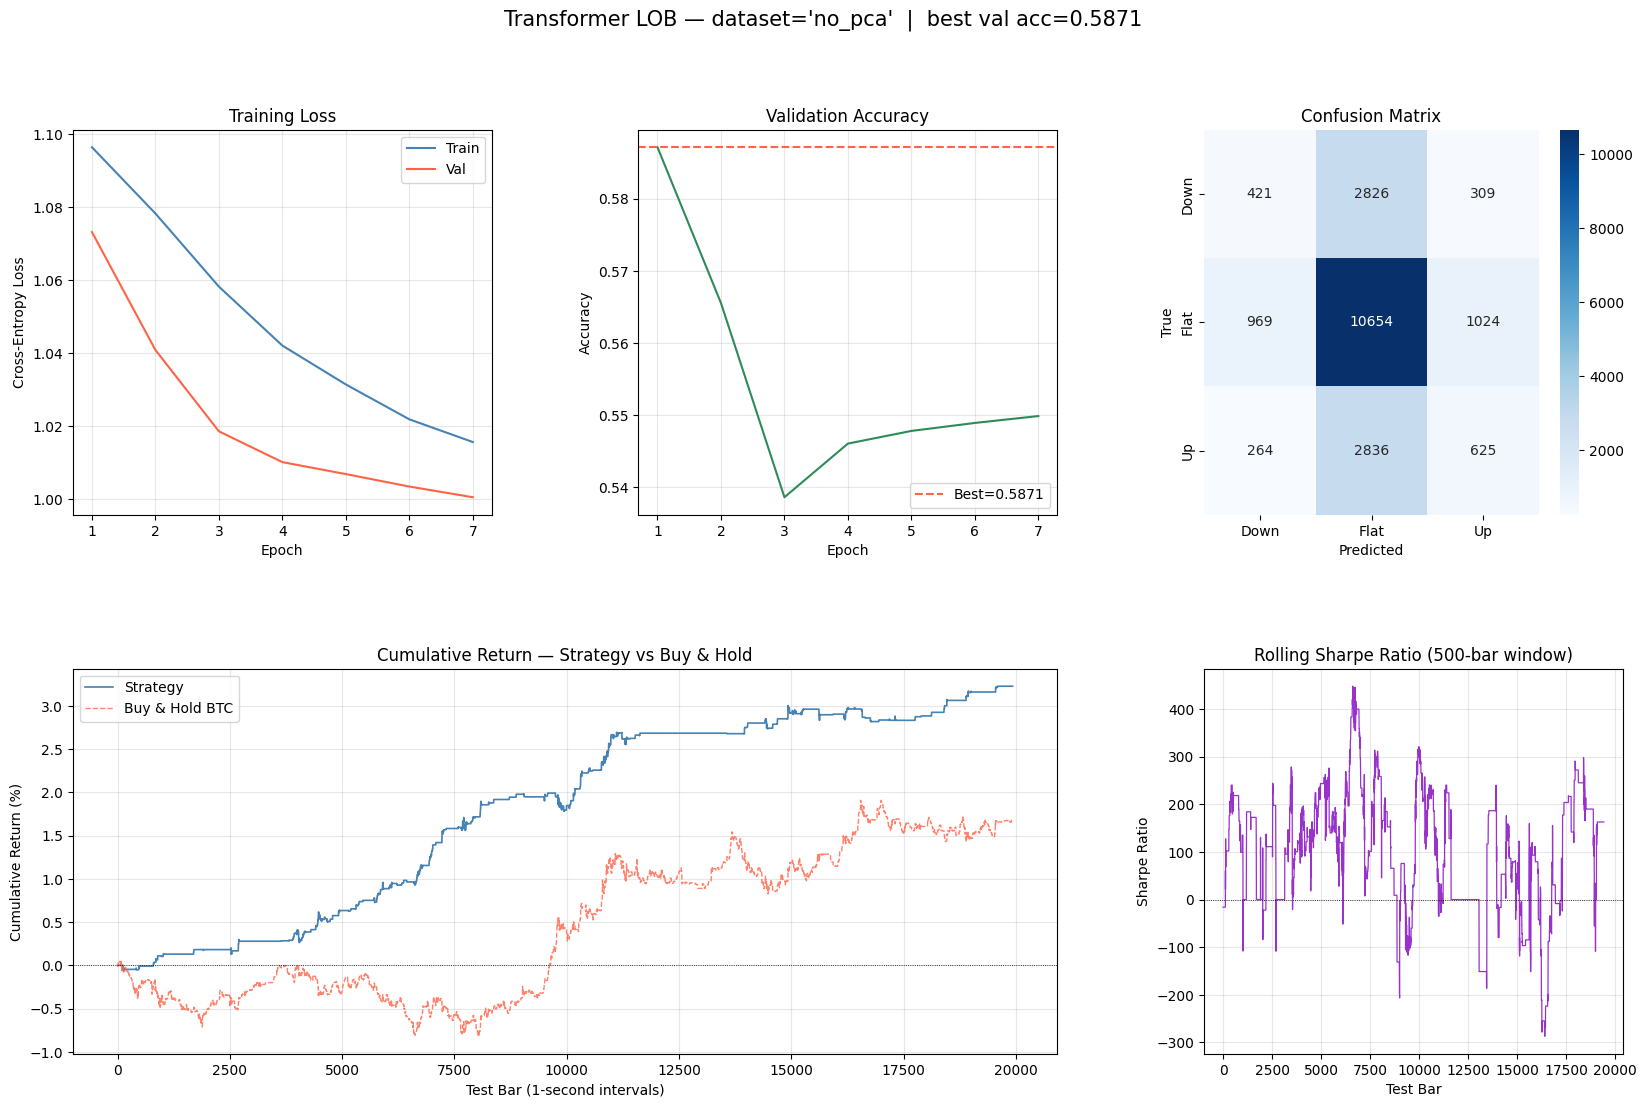

In [ ]:
import math, time
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ╔══════════════════════════════════════════════════════════════════╗
# ║              ★  CHOOSE YOUR INPUTS HERE  ★                      ║
# ║                                                                  ║
# ║  DATASET — which v4 dataset to train on:                        ║
# ║    "full"      → df_full      (PCA top-N + market + classic)    ║
# ║    "no_pca"    → df_no_pca   (raw Z-scored LOB + market         ║
# ║                                + classic, no PCA)               ║
# ║    "no_market" → df_no_market (PCA top-N + classic only)        ║
# ║                                                                  ║
# ║  TRANSACTION_COST: one-way cost per trade (e.g. 0.0005 = 5bps)  ║
# ╚══════════════════════════════════════════════════════════════════╝
DATASET          = "no_pca"    # ← change me: "full" | "no_pca" | "no_market"
TRANSACTION_COST = 0            # ← change me: one-way cost per trade

# ── Config ────────────────────────────────────────────────────────────────────
SEED       = 42
SEQ_LEN    = 30
D_MODEL    = 64
N_HEADS    = 4
N_LAYERS   = 3
D_FF       = 128
DROPOUT    = 0.1
BATCH_SIZE = 256
EPOCHS     = 30
LR         = 3e-4
PATIENCE   = 6

# Meta columns produced by the v4 pipeline — never used as features
META_COLS = ["label", "future_return", "split"]

torch.manual_seed(SEED); np.random.seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")


# ══════════════════════════════════════════════════════════════════════════════
# STEP 1 — Dataset Selection
# ══════════════════════════════════════════════════════════════════════════════
def select_dataset(dataset: str):
    """
    Reads one of the three v4 exported DataFrames, strips meta columns,
    and returns (X_train, X_test, y_train, y_test) using the pre-computed
    'split' column from the pipeline (no re-splitting needed).

    dataset:
      "full"      → df_full      (PCA top-N + market + classic)
      "no_pca"    → df_no_pca    (raw Z-scored LOB + market + classic)
      "no_market" → df_no_market (PCA top-N + classic only)
    """
    dataset_map = {
        "full":      BTC_ETH_pipeline_v4.df_full,
        "no_pca":    BTC_ETH_pipeline_v4.df_no_pca,
        "no_market": BTC_ETH_pipeline_v4.df_no_market,
    }
    assert dataset in dataset_map, \
        f"DATASET must be one of {list(dataset_map.keys())}, got '{dataset}'"

    dset = dataset_map[dataset]

    # Feature columns = everything except meta
    feature_cols = [c for c in dset.columns if c not in META_COLS]

    # Honoring the pipeline's own train/test split flag
    train_mask = dset["split"] == "train"
    test_mask  = dset["split"] == "test"

    X_train = dset.loc[train_mask, feature_cols].values.astype(np.float32)
    X_test  = dset.loc[test_mask,  feature_cols].values.astype(np.float32)

    # Labels: {-1, 0, 1} → {0, 1, 2}  (required by nn.CrossEntropyLoss)
    y_train = (dset.loc[train_mask, "label"].values + 1).astype(np.int64)
    y_test  = (dset.loc[test_mask,  "label"].values + 1).astype(np.int64)

    print(f"\nDataset     : {dataset}")
    print(f"Features    : {len(feature_cols)}  →  {feature_cols[:4]} ...")
    print(f"Train shape : {X_train.shape}  |  Test shape : {X_test.shape}")
    print(f"Label dist (train) — "
          f"Down:{(y_train==0).sum():,}  Flat:{(y_train==1).sum():,}  Up:{(y_train==2).sum():,}")

    # Number of train rows in the original df (needed for backtest alignment)
    split_idx = int(train_mask.sum())

    return X_train, X_test, y_train, y_test, split_idx


# ══════════════════════════════════════════════════════════════════════════════
# STEP 2 — Dataset & DataLoaders
# ══════════════════════════════════════════════════════════════════════════════
class LOBDataset(Dataset):
    def __init__(self, X, y, seq_len):
        self.X       = torch.tensor(X, dtype=torch.float32)
        self.y       = torch.tensor(y, dtype=torch.long)
        self.seq_len = seq_len

    def __len__(self):
        return len(self.X) - self.seq_len + 1

    def __getitem__(self, i):
        return self.X[i : i + self.seq_len], self.y[i + self.seq_len - 1]


def build_loaders(X_train, X_test, y_train, y_test):
    """
    Features are already rolling-Z-scored by the v4 pipeline,
    so no additional StandardScaler is needed here.
    """
    counts  = np.bincount(y_train, minlength=3).astype(float)
    class_w = torch.tensor(counts.sum() / (3 * counts), dtype=torch.float32).to(DEVICE)

    train_loader = DataLoader(LOBDataset(X_train, y_train, SEQ_LEN),
                              batch_size=BATCH_SIZE, shuffle=False)
    test_loader  = DataLoader(LOBDataset(X_test,  y_test,  SEQ_LEN),
                              batch_size=BATCH_SIZE * 2, shuffle=False)

    print(f"Train samples : {len(train_loader.dataset):,}  |  "
          f"Test samples  : {len(test_loader.dataset):,}")
    print(f"Class weights (down/flat/up) : {class_w.cpu().numpy().round(3)}")
    return train_loader, test_loader, class_w


# ══════════════════════════════════════════════════════════════════════════════
# STEP 3 — Model
# ══════════════════════════════════════════════════════════════════════════════
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, : x.size(1)])


class LOBTransformer(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.proj    = nn.Linear(n_features, D_MODEL)
        self.pos_enc = PositionalEncoding(D_MODEL, dropout=DROPOUT)
        enc_layer    = nn.TransformerEncoderLayer(
            D_MODEL, N_HEADS, D_FF, DROPOUT,
            activation="gelu", batch_first=True, norm_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, N_LAYERS, norm=nn.LayerNorm(D_MODEL))
        self.head    = nn.Sequential(
            nn.Linear(D_MODEL, D_MODEL // 2), nn.GELU(), nn.Dropout(DROPOUT),
            nn.Linear(D_MODEL // 2, 3)
        )
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.pos_enc(self.proj(x))    # (B, T, D_MODEL)
        x = self.encoder(x).mean(dim=1)   # mean-pool over time
        return self.head(x)


def build_model(n_features):
    model    = LOBTransformer(n_features).to(DEVICE)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Model params : {n_params:,}  |  Input features : {n_features}")
    return model


# ══════════════════════════════════════════════════════════════════════════════
# STEP 4 — Training
# ══════════════════════════════════════════════════════════════════════════════
def train(model, train_loader, test_loader, class_w):
    criterion = nn.CrossEntropyLoss(weight=class_w, label_smoothing=0.05)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    history = {"train_loss": [], "val_loss": [], "val_acc": []}
    best_acc, best_state, patience_cnt = 0.0, None, 0

    for epoch in range(1, EPOCHS + 1):
        model.train(); running = 0.0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            running += loss.item() * len(yb)
        scheduler.step()
        train_loss = running / len(train_loader.dataset)

        model.eval(); vloss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for Xb, yb in test_loader:
                Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
                logits  = model(Xb)
                vloss  += criterion(logits, yb).item() * len(yb)
                correct += (logits.argmax(1) == yb).sum().item()
                total   += len(yb)
        val_loss = vloss / total
        val_acc  = correct / total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        print(f"Ep {epoch:3d}/{EPOCHS} | "
              f"Train Loss {train_loss:.4f} | Val Loss {val_loss:.4f} | Val Acc {val_acc:.4f}")

        if val_acc > best_acc:
            best_acc, patience_cnt = val_acc, 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_cnt += 1
            if patience_cnt >= PATIENCE:
                print(f"Early stop at epoch {epoch}. Best val acc: {best_acc:.4f}")
                break

    model.load_state_dict(best_state)
    return history, best_acc


# ══════════════════════════════════════════════════════════════════════════════
# STEP 5 — Prediction
# ══════════════════════════════════════════════════════════════════════════════
def predict(model, test_loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for Xb, yb in test_loader:
            all_preds.append(model(Xb.to(DEVICE)).argmax(1).cpu().numpy())
            all_labels.append(yb.numpy())
    return np.concatenate(all_preds), np.concatenate(all_labels)


# ══════════════════════════════════════════════════════════════════════════════
# STEP 6.1 — Statistical Prediction Metrics
# ══════════════════════════════════════════════════════════════════════════════
def statistical_metrics(y_true, y_pred):
    """
    Classification accuracy, precision, recall, and F1-score
    for the Down, Flat, and Up classes.
    """
    print("\n" + "=" * 60)
    print("  6.1  STATISTICAL PREDICTION METRICS")
    print("=" * 60)

    acc = (y_pred == y_true).mean()
    print(f"\nOverall Accuracy : {acc:.4f}  ({acc*100:.2f}%)\n")

    target_names = ["Down (-1)", "Flat (0)", "Up (+1)"]
    print(classification_report(y_true, y_pred, target_names=target_names, digits=4))

    prec, rec, f1, sup = precision_recall_fscore_support(
        y_true, y_pred, labels=[0, 1, 2], zero_division=0
    )
    print(f"\n{'Class':<12} {'Precision':>10} {'Recall':>10} {'F1-Score':>10} {'Support':>10}")
    print("-" * 46)
    for i, name in enumerate(target_names):
        print(f"{name:<12} {prec[i]:>10.4f} {rec[i]:>10.4f} {f1[i]:>10.4f} {sup[i]:>10,}")

    return dict(accuracy=acc, precision=prec, recall=rec, f1=f1, support=sup)


# ══════════════════════════════════════════════════════════════════════════════
# STEP 6.2 — Economic Evaluation & Backtesting
# ══════════════════════════════════════════════════════════════════════════════
def backtest(y_pred, split_idx, transaction_cost=0.0005):
    """
    Simple long / short / neutral strategy on the test set.

    Signal mapping (predictions in {0, 1, 2}):
      0 (Down) → short  (-1)
      1 (Flat) → hold    (0)
      2 (Up)   → long   (+1)

    Actual log-returns come from df['log_return'] in the v4 pipeline scope,
    aligned to the test window via split_idx and SEQ_LEN.

    Metrics: cumulative return, annualised Sharpe ratio,
             maximum drawdown, total trades, turnover.
    """
    print("\n" + "=" * 60)
    print("  6.2  ECONOMIC EVALUATION & BACKTESTING")
    print("=" * 60)

    # ── Align actual log-returns to the test window ───────────────────────────
    # The sliding window of SEQ_LEN means the first prediction corresponds
    # to index (split_idx + SEQ_LEN - 1) in df.
    log_ret_full = BTC_ETH_pipeline_v4.df['log_return'].values
    test_start   = split_idx + SEQ_LEN - 1
    test_end     = test_start + len(y_pred)
    actual_ret   = log_ret_full[test_start:test_end].astype(np.float64)

    # ── Positions ─────────────────────────────────────────────────────────────
    signal_map = {0: -1, 1: 0, 2: 1}
    positions  = np.array([signal_map[p] for p in y_pred], dtype=np.float64)

    # ── Transaction costs on every position change ────────────────────────────
    trade_mask  = (np.diff(positions, prepend=0) != 0).astype(float)
    cost_series = trade_mask * transaction_cost

    # ── Returns ───────────────────────────────────────────────────────────────
    strat_ret = positions * actual_ret - cost_series
    bh_ret    = actual_ret

    cum_strat = np.cumprod(1 + strat_ret) - 1
    cum_bh    = np.cumprod(1 + bh_ret)   - 1

    # ── Annualised Sharpe ratio ───────────────────────────────────────────────
    # 1-second bars: 252 trading days × 23,400 seconds per day
    BARS_PER_YEAR = 252 * 23_400
    sr_strat = (strat_ret.mean() / (strat_ret.std() + 1e-8)) * np.sqrt(BARS_PER_YEAR)
    sr_bh    = (bh_ret.mean()    / (bh_ret.std()    + 1e-8)) * np.sqrt(BARS_PER_YEAR)

    # ── Maximum drawdown ──────────────────────────────────────────────────────
    def max_drawdown(cum):
        equity = 1 + cum
        peak   = np.maximum.accumulate(equity)
        return ((equity - peak) / (peak + 1e-8)).min()

    mdd_strat = max_drawdown(cum_strat)
    mdd_bh    = max_drawdown(cum_bh)

    # ── Turnover ──────────────────────────────────────────────────────────────
    n_trades = int(trade_mask.sum())
    turnover = trade_mask.mean()

    # ── Summary table ─────────────────────────────────────────────────────────
    print(f"\n{'Metric':<30} {'Strategy':>12} {'Buy & Hold':>12}")
    print("-" * 56)
    print(f"{'Cumulative Return':<30} {cum_strat[-1]:>12.4f} {cum_bh[-1]:>12.4f}")
    print(f"{'Annualised Sharpe Ratio':<30} {sr_strat:>12.4f} {sr_bh:>12.4f}")
    print(f"{'Maximum Drawdown':<30} {mdd_strat:>12.4f} {mdd_bh:>12.4f}")
    print(f"{'Total Trades':<30} {n_trades:>12,} {'—':>12}")
    print(f"{'Turnover (per bar)':<30} {turnover:>12.4f} {'—':>12}")
    print(f"{'Transaction Cost (one-way)':<30} {transaction_cost:>12.4f} {'—':>12}")

    bt_metrics = dict(
        cum_return_strat   = cum_strat[-1],
        cum_return_bh      = cum_bh[-1],
        sharpe_strat       = sr_strat,
        sharpe_bh          = sr_bh,
        max_drawdown_strat = mdd_strat,
        max_drawdown_bh    = mdd_bh,
        n_trades           = n_trades,
        turnover           = turnover,
    )
    return bt_metrics, cum_strat, cum_bh, strat_ret


# ══════════════════════════════════════════════════════════════════════════════
# STEP 7 — Plots
# ══════════════════════════════════════════════════════════════════════════════
def plot_results(history, y_pred, y_true, cum_strat, cum_bh, strat_ret, title=""):
    fig = plt.figure(figsize=(20, 12))
    fig.suptitle(f"Transformer LOB — {title}", fontsize=15)
    gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

    # ── Row 0 : training diagnostics ─────────────────────────────────────────
    ax0 = fig.add_subplot(gs[0, 0])
    ep  = range(1, len(history["train_loss"]) + 1)
    ax0.plot(ep, history["train_loss"], label="Train", color="steelblue")
    ax0.plot(ep, history["val_loss"],   label="Val",   color="tomato")
    ax0.set_title("Training Loss"); ax0.legend(); ax0.grid(alpha=0.3)
    ax0.set_xlabel("Epoch"); ax0.set_ylabel("Cross-Entropy Loss")

    ax1 = fig.add_subplot(gs[0, 1])
    best = max(history["val_acc"])
    ax1.plot(ep, history["val_acc"], color="seagreen")
    ax1.axhline(best, color="tomato", linestyle="--", label=f"Best={best:.4f}")
    ax1.set_title("Validation Accuracy"); ax1.legend(); ax1.grid(alpha=0.3)
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Accuracy")

    ax2 = fig.add_subplot(gs[0, 2])
    cm  = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax2,
                xticklabels=["Down", "Flat", "Up"],
                yticklabels=["Down", "Flat", "Up"])
    ax2.set_title("Confusion Matrix")
    ax2.set_xlabel("Predicted"); ax2.set_ylabel("True")

    # ── Row 1 : economic evaluation ───────────────────────────────────────────
    ax3 = fig.add_subplot(gs[1, :2])
    ax3.plot(cum_strat * 100, label="Strategy",       color="steelblue", linewidth=1.2)
    ax3.plot(cum_bh    * 100, label="Buy & Hold BTC", color="tomato",
             linewidth=1.0, linestyle="--", alpha=0.8)
    ax3.axhline(0, color="black", linewidth=0.6, linestyle=":")
    ax3.set_title("Cumulative Return — Strategy vs Buy & Hold")
    ax3.set_xlabel("Test Bar (1-second intervals)")
    ax3.set_ylabel("Cumulative Return (%)")
    ax3.legend(); ax3.grid(alpha=0.3)

    ax4 = fig.add_subplot(gs[1, 2])
    W     = 500
    r_mu  = np.convolve(strat_ret, np.ones(W) / W, mode="valid")
    r_std = np.array([strat_ret[i:i+W].std() for i in range(len(strat_ret) - W + 1)])
    ax4.plot(r_mu / (r_std + 1e-8) * np.sqrt(252 * 23_400),
             color="darkorchid", linewidth=0.9)
    ax4.axhline(0, color="black", linewidth=0.6, linestyle=":")
    ax4.set_title(f"Rolling Sharpe Ratio ({W}-bar window)")
    ax4.set_xlabel("Test Bar"); ax4.set_ylabel("Sharpe Ratio")
    ax4.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# STEP 8 — Full Pipeline
# ══════════════════════════════════════════════════════════════════════════════
def run_transformer(dataset: str, transaction_cost: float = 0.0005):
    """
    End-to-end pipeline: select dataset → build loaders → train
                         → 6.1 statistical metrics
                         → 6.2 economic evaluation & backtesting
                         → plots.

    Parameters
    ----------
    dataset          : "full" | "no_pca" | "no_market"
    transaction_cost : one-way cost per trade (default 5 bps)

    Reads from notebook scope
    -------------------------
    df_full, df_no_pca, df_no_market  — produced by BTC_ETH_pipeline_v4
    df                                — raw merged DataFrame (for log_return)
    """
    print("=" * 60)
    print(f"  Transformer LOB  |  dataset='{dataset}'  |  cost={transaction_cost}")
    print("=" * 60)

    X_train, X_test, y_train, y_test, split_idx = select_dataset(dataset)
    train_ld, test_ld, class_w                  = build_loaders(X_train, X_test,
                                                                 y_train, y_test)
    model = build_model(n_features=X_train.shape[1])

    print("\n--- Training ---")
    history, best_acc = train(model, train_ld, test_ld, class_w)

    print("\n--- Prediction ---")
    y_pred, y_true = predict(model, test_ld)

    # 6.1 Statistical prediction metrics
    stat_metrics = statistical_metrics(y_true, y_pred)

    # 6.2 Economic evaluation & backtesting
    bt_metrics, cum_strat, cum_bh, strat_ret = backtest(
        y_pred, split_idx=split_idx, transaction_cost=transaction_cost
    )

    plot_results(
        history, y_pred, y_true, cum_strat, cum_bh, strat_ret,
        title=f"dataset='{dataset}'  |  best val acc={best_acc:.4f}"
    )

    return model, history, stat_metrics, bt_metrics


# ══════════════════════════════════════════════════════════════════════════════
#  ★  ENTRY POINT
#     • Single run  : change DATASET / TRANSACTION_COST at the top
#     • Compare all : uncomment the three lines below
# ══════════════════════════════════════════════════════════════════════════════
model, history, stat_metrics, bt_metrics = run_transformer(DATASET, TRANSACTION_COST)

# --- compare all three datasets ---
# m1, h1, s1, b1 = run_transformer("full",      TRANSACTION_COST)
# m2, h2, s2, b2 = run_transformer("no_pca",    TRANSACTION_COST)
# m3, h3, s3, b3 = run_transformer("no_market", TRANSACTION_COST)

  Transformer LOB  |  dataset='no_market'  |  cost=0

Dataset     : no_market
Features    : 23  →  ['pca_1', 'pca_2', 'pca_3', 'pca_4'] ...
Train shape : (79826, 23)  |  Test shape : (19957, 23)
Label dist (train) — Down:17,975  Flat:44,145  Up:17,706
Train samples : 79,797  |  Test samples  : 19,928
Class weights (down/flat/up) : [1.48  0.603 1.503]
Model params : 104,259  |  Input features : 23

--- Training ---


/tmp/ipykernel_986/2939650347.py:158: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, N_LAYERS, norm=nn.LayerNorm(D_MODEL))


Ep   1/30 | Train Loss 1.1017 | Val Loss 1.0724 | Val Acc 0.5828
Ep   2/30 | Train Loss 1.0832 | Val Loss 1.0393 | Val Acc 0.5228
Ep   3/30 | Train Loss 1.0589 | Val Loss 1.0237 | Val Acc 0.5115
Ep   4/30 | Train Loss 1.0448 | Val Loss 1.0144 | Val Acc 0.5125
Ep   5/30 | Train Loss 1.0364 | Val Loss 1.0081 | Val Acc 0.5370
Ep   6/30 | Train Loss 1.0296 | Val Loss 1.0075 | Val Acc 0.5473
Ep   7/30 | Train Loss 1.0280 | Val Loss 1.0075 | Val Acc 0.5461
Early stop at epoch 7. Best val acc: 0.5828

--- Prediction ---

  6.1  STATISTICAL PREDICTION METRICS

Overall Accuracy : 0.5828  (58.28%)

              precision    recall  f1-score   support

   Down (-1)     0.2726    0.1676    0.2076      3556
    Flat (0)     0.6576    0.8136    0.7273     12647
     Up (+1)     0.3481    0.1957    0.2506      3725

    accuracy                         0.5828     19928
   macro avg     0.4261    0.3923    0.3952     19928
weighted avg     0.5311    0.5828    0.5455     19928


Class         Precisio

/tmp/ipykernel_986/2939650347.py:417: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


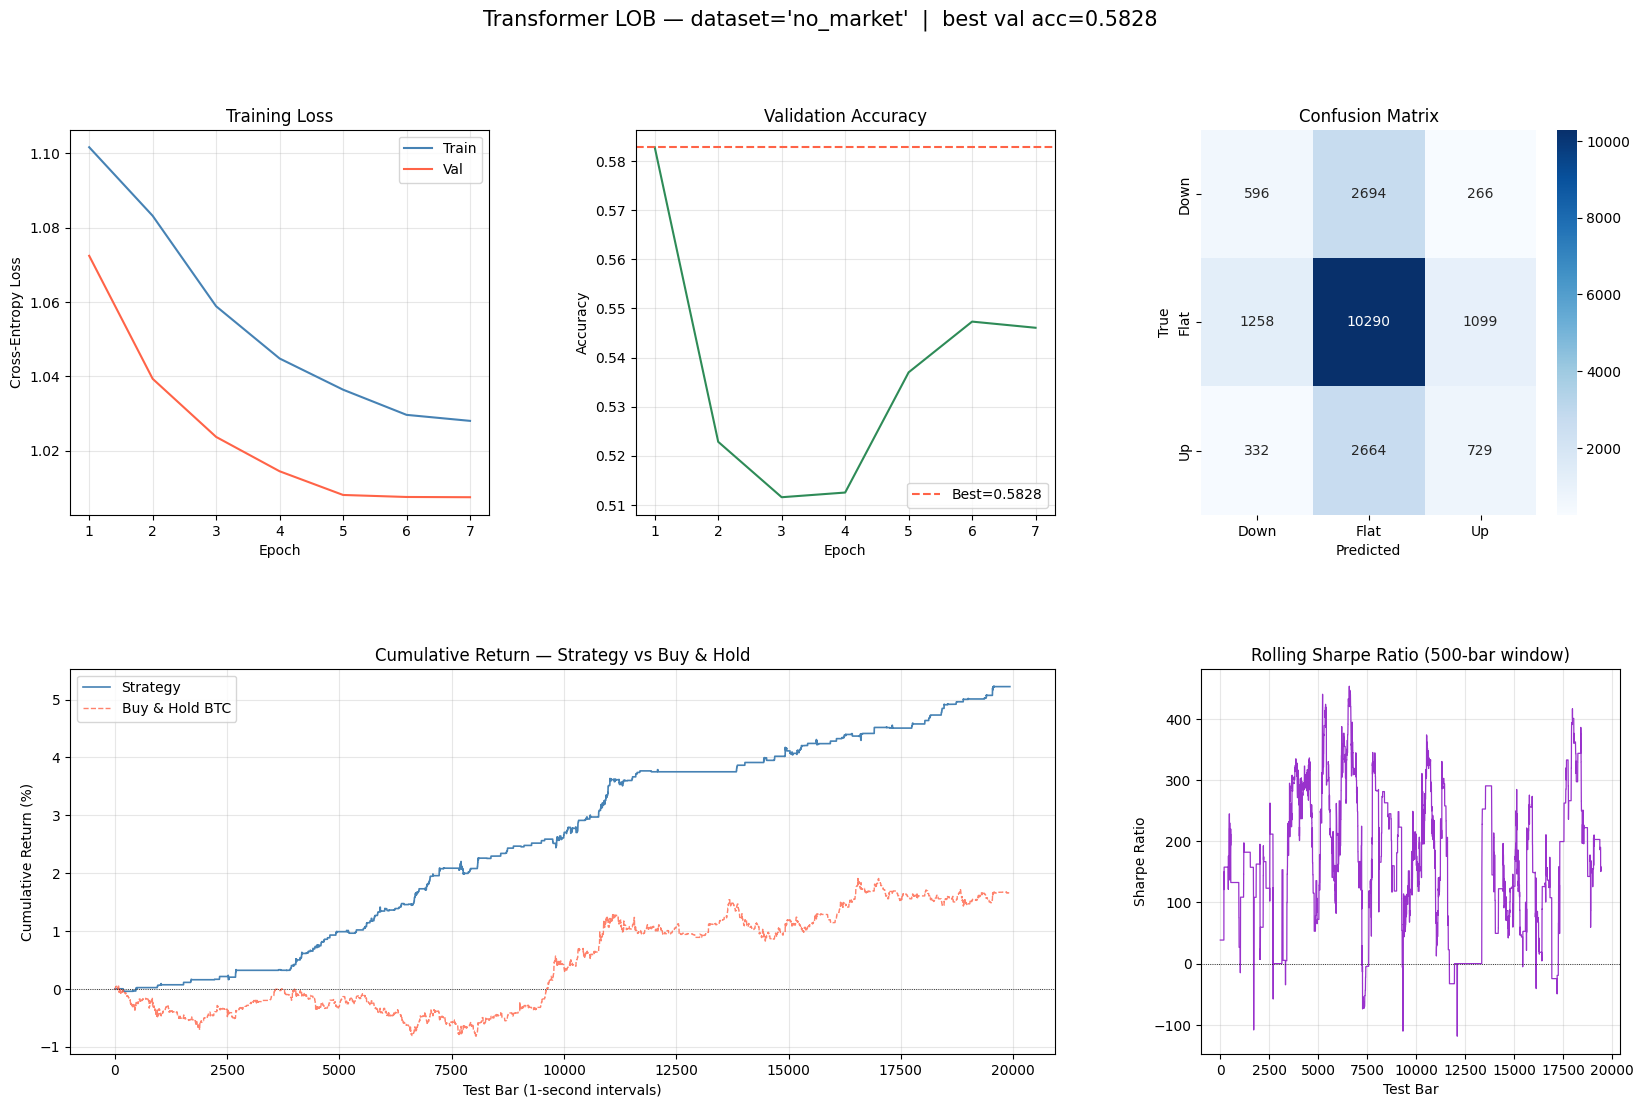

In [ ]:
FEATURE_SET = "no_market"
TRANSACTION_COST = 0
model, history, stat_metrics, bt_metrics = run_transformer(FEATURE_SET, TRANSACTION_COST)

  Transformer LOB  |  dataset='full'  |  cost=0

Dataset     : full
Features    : 38  →  ['pca_1', 'pca_2', 'pca_3', 'pca_4'] ...
Train shape : (79826, 38)  |  Test shape : (19957, 38)
Label dist (train) — Down:17,975  Flat:44,145  Up:17,706
Train samples : 79,797  |  Test samples  : 19,928
Class weights (down/flat/up) : [1.48  0.603 1.503]
Model params : 105,219  |  Input features : 38

--- Training ---


/tmp/ipykernel_986/2939650347.py:158: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, N_LAYERS, norm=nn.LayerNorm(D_MODEL))


Ep   1/30 | Train Loss 1.1024 | Val Loss 1.0692 | Val Acc 0.5499
Ep   2/30 | Train Loss 1.0829 | Val Loss 1.0527 | Val Acc 0.5372
Ep   3/30 | Train Loss 1.0590 | Val Loss 1.0189 | Val Acc 0.5208
Ep   4/30 | Train Loss 1.0393 | Val Loss 1.0063 | Val Acc 0.5351
Ep   5/30 | Train Loss 1.0301 | Val Loss 0.9999 | Val Acc 0.5425
Ep   6/30 | Train Loss 1.0237 | Val Loss 0.9961 | Val Acc 0.5535
Ep   7/30 | Train Loss 1.0180 | Val Loss 0.9943 | Val Acc 0.5584
Ep   8/30 | Train Loss 1.0149 | Val Loss 0.9941 | Val Acc 0.5532
Ep   9/30 | Train Loss 1.0104 | Val Loss 0.9923 | Val Acc 0.5503
Ep  10/30 | Train Loss 1.0052 | Val Loss 0.9950 | Val Acc 0.5476
Ep  11/30 | Train Loss 1.0006 | Val Loss 0.9985 | Val Acc 0.5445
Ep  12/30 | Train Loss 0.9959 | Val Loss 0.9990 | Val Acc 0.5499
Ep  13/30 | Train Loss 0.9916 | Val Loss 1.0018 | Val Acc 0.5465
Early stop at epoch 13. Best val acc: 0.5584

--- Prediction ---

  6.1  STATISTICAL PREDICTION METRICS

Overall Accuracy : 0.5584  (55.84%)

             

/tmp/ipykernel_986/2939650347.py:417: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


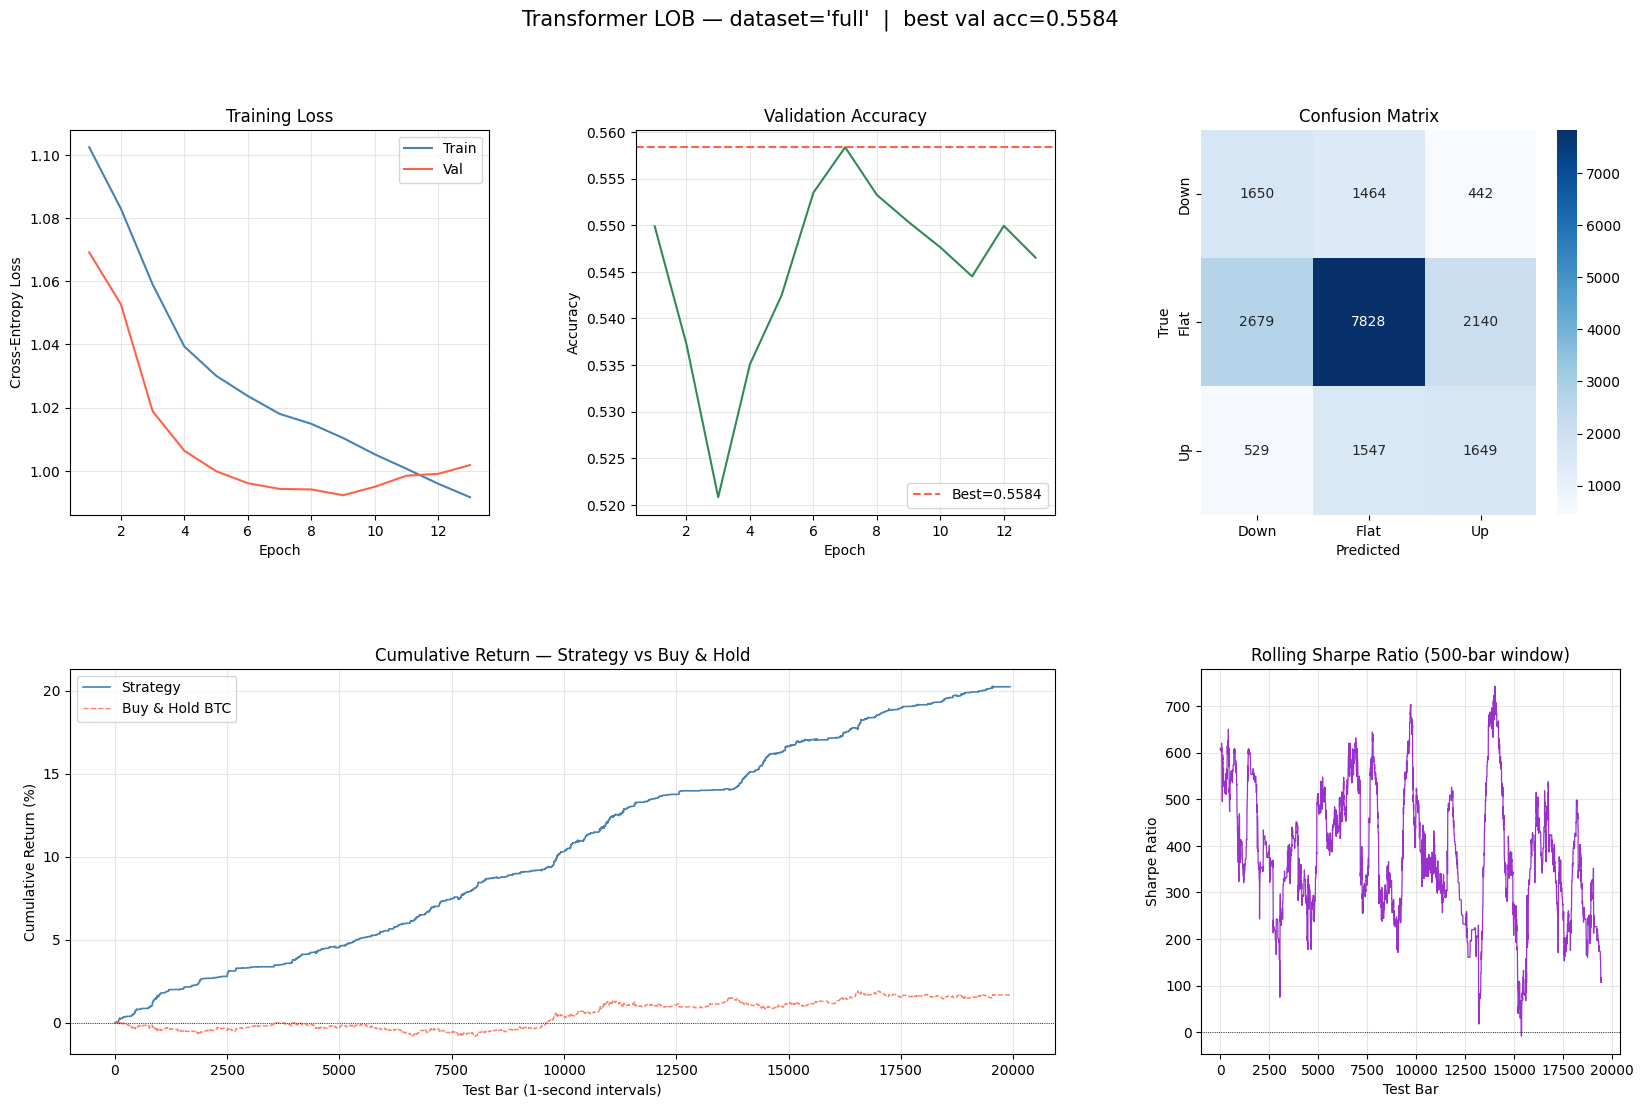

In [ ]:
# full model
FEATURE_SET = "full"
TRANSACTION_COST = 0
model, history, stat_metrics, bt_metrics = run_transformer(FEATURE_SET, TRANSACTION_COST)